# Исследование рынка общественного питания г. Москвы

- **Автор**: Даулетжан Баймуханов
- **Дата**: 07.12.2025

### Цели и задачи проекта

**Цель**: Провести исследовательский анализ данных заведений общественного питания города Москвы с выявлением наиболее популярных категорий заведений, сетей и районов.

**Задачи**:
1. Загрузить данные и познакомиться с их содержанием;
2. Провести предобработку данных;
3. Провести исследовательский анализ данных:
    - изучить данные более детально, уделив внимание категориям, расположению, сетевой принадлежности, количеству посадочных мест, и рейтингу заведений;
    - изучить соотношение сетевых и несетевых заведений;
    - изучить взаимосвязь данных в столбце rating с другими данными;
    - найти топ-15 популярных сетей в Москве.
4. Сформулировать выводы по проведённому анализу.

### Описание данных

Для анализа были представлены датасеты на основе данных сервисов `Яндекс Карты` и `Яндекс Бизнес` на лето 2022 года. Данные состоят из двух датасетов:
- `/datasets/rest_info.csv` - информация о заведениях общественного питания;
- `/datasets/rest_price.csv` - информация о среднем чеке в заведениях общественного питания.

#### Описание датасета `/datasets/rest_info.csv`:

- `id` - идентификатор заведения;
- `name` — название заведения;
- `address` — адрес заведения;
- `district` — административный район, в котором находится заведение;
- `category` — категория заведения;
- `hours` — информация о днях и часах работы;
- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах;
- `chain` — является ли заведение сетевым; 
- `seats` — количество посадочных мест.


#### Описание датасета `/datasets/rest_price.csv`:

- `id` - идентификатор заведения;
- `price` — категория цен в заведении;
- `avg_bill` — средняя стоимость заказа в виде диапазона; 
- `middle_avg_bill` — оценка среднего чека; 
- `middle_coffee_cup` — оценка стоимости одной чашки капучино.

### Содержимое проекта

1.	[Загрузка данных и знакомство с ними](#chapter_one).
2.	[Предобработка данных](#chapter_two).
3.	[Исследовательский анализ данных](#chapter_three).
4.	[Итоговые выводы и рекомендации](#chapter_four).

---

<a id='chapter_one'></a>
## 1. Загрузка данных и знакомство с ними

Начнём с загрузки библиотек и датасетов `/datasets/rest_info.csv` и `/datasets/rest_price.csv`. Будем использовать pandas и библиотеки визуализации данных matplotlib и seaborn, а также phik_matrix для построения матрицы корреляции. Данные датасетов сохраним в двух переменных: `rest_info_df` и `rest_price_df`.

In [1]:
# Устанавливаем библиотеку phik
!pip install phik

     |████████████████████████████████| 677 kB 1.9 MB/s eta 0:00:01


In [2]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix

In [3]:
# Выгружаем данные в переменные rest_info_df и rest_price_df
rest_info_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
rest_price_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

Познакомимся с данными датасета `rest_info.csv` и изучим общую информацию, которая хранится в нем.

In [4]:
# Выводим первые строки датафрейма на экран
rest_info_df.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [5]:
# Выводим информацию о датафрейме
rest_info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


Датасет `rest_info.csv` содержит 9 столбцов и 8406 строк, в которых представлена информация о заведениях общественного питания города Москвы.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов представлены корректно, их не нужно обрабатывать.
- Представленные данные содержат как числовые, так и не числовые данные. Не числовых данных в датасете больше всего, их 6, и они хранятся в типе данных `object`. Столбцов с числовыми данными 3, в двух (2) из них данных хранятся в типе `float64`, а в одном – `int64`. Столбец `chain` содержит значения 1 или 0 — размерность этих данных можно оптимизировать. Также можно оптимизировать размерность данных в столбце `rating`, который содержит ограниченное количество рейтингов от 1.0 до 5.0.
- Пропуски содержатся в столбцах `hours` и `seats`. Однако следует проверить и другие столбцы: в них могут встречаться значения-индикаторы, которые будут говорить об отсутствии данных.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.


Познакомимся с данными датасета `rest_price.csv` и изучим общую информацию, которая хранится в нем.

In [6]:
# Выводим первые строки датафрейма на экран
rest_price_df.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [7]:
# Выводим информацию о датафрейме
rest_price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


Датасет `est_price.csv` содержит 5 столбцов и 4057 строк, в которых представлена информация о ценовой политике заведений общественного питания города Москвы. После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов представлены корректно, их не нужно обрабатывать.
- Представленные данные содержат как числовые, так и не числовые данные. Столбцов, которые содержан числовые данные – два (2), а не числовые данные – три (3). Все числовые данные хранятся типе `float64`.
- Пропуски содержатся во всех столбцах, кроме столбца, хранящего ключи – `id`.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.


---

### Промежуточный вывод

Первичное знакомство показывает, что в данных имеются пропуски, особенно их много во втором датасете (`rest_price.csv`), сами данные соответствуют описанию и выглядят корректными. Кроме этого, использованные типы данных в столбцах датасетов выглядят верными. В двух столбцах датасета `rest_info.csv`, а именно – `chain` и `rating`, можно провести оптимизацию. Также, учитывая большое количество пропусков и связанность данных между собой в датасете `rest_price.csv` нужно обратить внимание на возможные пути заполнения пропусков. Например, пропуски в столбце `price` (категория цен) можно заполнить на основе данных из столбца `middle_avg_bill` (оценка среднего чека).

### Подготовка единого датафрейма

Данное исследование предполагает анализ рынка заведений общественного питания города Москвы. Большая часть необходимых для этого исследования данных хранятся в датасете `rest_info_df`, а датасет `rest_price_df` представляет собой дополнительную справочную информацию, добавленную пользователями или найденную в общедоступных источниках. Поэтому к датасету `rest_info_df` нужно добавить датасет `rest_price_df`, используя значение параметра `how` – `left`. Это позволит сохранить данные о всех заведениях, добавив к ним информацию о ценах, при наличии.

In [8]:
# Соединяем данные в единый датафрейм df
df = rest_info_df.merge(rest_price_df, on='id', how='left')

In [9]:
# Выводим первые строки датафрейма на экран
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


In [10]:
# Выводим информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


Данные соединены, и информация обо всех заведениях сохранилась.

<a id='chapter_two'></a>
## 2. Предобработка данных

Готовим данные к исследовательскому анализу.

### Оптимизируем типы данных

В датасете можно оптимизировать данные в двух столбцах – `chain` и `rating`, которых хранятся числовые данные, уменьшив их битовый разряд. Также для удобства можно поменять тип в таблицах хранящих категориальные данные, таких как `category` и `district`, с `object` на `category`.

In [11]:
# Оптимизируем целочисленный тип данных в столбце chain
df['chain'] = pd.to_numeric(df['chain'], downcast='integer')

In [12]:
# Оптимизируем вещественный тип данных в столбце rating
df['rating'] = pd.to_numeric(df['rating'], downcast='float')

In [13]:
# Исправляем тип данных, в таблицах хранящих категориальные данные
df[['category', 'district']] = df[['category', 'district']].astype('category')

In [14]:
# Выводим информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   id                 8406 non-null   object  
 1   name               8406 non-null   object  
 2   category           8406 non-null   category
 3   address            8406 non-null   object  
 4   district           8406 non-null   category
 5   hours              7870 non-null   object  
 6   rating             8406 non-null   float32 
 7   chain              8406 non-null   int8    
 8   seats              4795 non-null   float64 
 9   price              3315 non-null   object  
 10  avg_bill           3816 non-null   object  
 11  middle_avg_bill    3149 non-null   float64 
 12  middle_coffee_cup  535 non-null    float64 
dtypes: category(2), float32(1), float64(3), int8(1), object(6)
memory usage: 714.9+ KB


Оптимизация типов данных прошла успешно.

### Изучаем пропущенные значения в данных

При первичном анализе мы обнаружили пропуски в столбцах `hours` и `seats` датафрейма `rest_info_df`, а также в столбцах `price`, `avg_bill`, `middle_avg_bill` и `middle_coffee_cup` датафрейма `rest_price_df`. Узнаем абсолютное и относительное количество пропусков в этом столбце.

In [15]:
# Применяем метод isna() к единому датафрейму df
df.isna().sum()

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

In [16]:
# Подсчитываем долю строк с пропусками
round(df.isna().sum() / df.shape[0] * 100, 2)

id                    0.00
name                  0.00
category              0.00
address               0.00
district              0.00
hours                 6.38
rating                0.00
chain                 0.00
seats                42.96
price                60.56
avg_bill             54.60
middle_avg_bill      62.54
middle_coffee_cup    93.64
dtype: float64

В датафрейме df обнаружено: 
- 536 пропусков в столбце `hours` — это 6,4% данных;
- 3611 пропусков в столбце `seats` — это 43% данных;
- 5091 пропусков в столбце `price` — это 60,6% данных;
- 4590 пропусков в столбце `avg_bill` — это 54,6% данных;
- 5257 пропусков в столбце `middle_avg_bill` — это 62,5% данных;
- 7871 пропусков в столбце `middle_coffee_cup` — это 93,6% данных.

Большое количество пропусков приходится на столбцы `price`, `avg_bill`, `middle_avg_bill` и `middle_coffee_cup` из файла `rest_price.csv`, в котором хранятся данные справочного характера. Данные в столбцах `price` и `avg_bill` были добавлены пользователями или найдены в общедоступных источниках, а столбцы `middle_avg_bill` и `middle_coffee_cup` были заполнены на основе данных столбца `avg_bill`. Другими словами, пропуски в столбце `avg_bill` приводят к пропускам в других столбцах. Поэтому можно проверить возможность заполнения пропусков в столбцах `middle_avg_bill`, `middle_coffee_cup` и `price` на основе данных из столбца `avg_bill`, при его наличии в строке.

Наименьшее количество пропусков встречается в столбце `hours`. В целом количество пропусков достаточно большое, чтобы их просто удалить. Их заполнение средними данными по району расположения и категории заведения могут привести к искажению результатов исследования.


Проверяем возможность заполнения пропусков на основе данных столбца avg_bill.

In [17]:
# Проверяем наличие заполнения обоих столбцов - avg_bill и middle_coffee_cup – на основе столбца avg_bill
df[df['avg_bill'].notna() & df['middle_avg_bill'].notna() & df['middle_coffee_cup'].notna()]['id'].count()

0

Убедились, что столбец `avg_bill` может хранить информацию только об одной категории.

In [18]:
# Считаем количество строк, где имеются данные в столбце avg_bill, но отсутствуют данные в других производных столбцах
df[df['avg_bill'].notna() & df['middle_avg_bill'].isna() & df['middle_coffee_cup'].isna()]['id'].count()

132

Таких строк 132.

In [19]:
# Выводим первые пять строк для ознакомления
df[df['avg_bill'].notna() & df['middle_avg_bill'].isna() & df['middle_coffee_cup'].isna()].head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
10,ac32978af97641bfacf996e7f5a50ee5,Great Room Bar,"бар,паб","Москва, Левобережная улица, 12",Северный административный округ,"ежедневно, круглосуточно",4.5,0,102.0,средние,Цена бокала пива:250–350 ₽,NaN,NaN
67,fca6820ccef64456b90326102d6aebb7,Штаб квартира,"бар,паб","Москва, Дубнинская улица, 32",Северный административный округ,"пн-чт 12:30–00:00; пт,сб 12:30–02:00; вс 12:30...",5.0,0,16.0,средние,Цена бокала пива:120–350 ₽,NaN,NaN
97,670b0b0cf7f449078be63932ee9f2139,Жигулевское,"бар,паб","Москва, Бибиревская улица, 7к2",Северо-Восточный административный округ,"пн-чт 14:00–00:00; пт,сб 14:00–02:00; вс 14:00...",4.5,0,NaN,средние,Цена бокала пива:90–230 ₽,NaN,NaN
241,ac6218d4cd524f359ba9dbd6ae22dada,Алиби,"бар,паб","Москва, улица Малыгина, 1, стр. 2",Северо-Восточный административный округ,пн-чт 11:00–00:00; пт-вс 11:00–05:00,4.4,0,40.0,выше среднего,Цена бокала пива:160–499 ₽,NaN,NaN
417,6ac0e6250be341b7b76cfa1d8047392a,Сибирская Корона,"бар,паб","Москва, Планерная улица, 12к1",Северо-Западный административный округ,"ежедневно, 12:00–00:00",4.3,0,NaN,средние,Цена бокала пива:199–300 ₽,NaN,NaN


На первый взгляд в строках хранится информация о ценах на бокал пива. Возможно, эти строки относятся к категории бар и паб. Необходимо проверить категорию представленных в выборке заведений.

In [20]:
# Проверяем уникальные категории заведений в выборке 
df[df['avg_bill'].notna() & df['middle_avg_bill'].isna() & df['middle_coffee_cup'].isna()]['category'].unique()

['бар,паб', 'пиццерия']
Categories (2, object): ['бар,паб', 'пиццерия']

В выборке представлены только категории `бар,паб` и `пиццерия`.

In [21]:
# Проверяем количество пиццерий в выборке
df[df['avg_bill'].notna() & df['middle_avg_bill'].isna() & df['middle_coffee_cup'].isna() & (df['category']=='пиццерия')]

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
6530,485e6fcc083d42f7844e967317b4910f,Торнано,пиццерия,"Москва, проспект Вернадского, 92",Западный административный округ,"ежедневно, 12:00–00:00",4.0,0,18.0,NaN,Цена бокала пива:140–190 ₽,NaN,NaN
6910,5ba954dd7506480fa712ef641ccd9a44,Harvest Cocktail Bar,пиццерия,"Москва, улица Бутлерова, 17Б",Юго-Западный административный округ,"ежедневно, 10:00–03:00",4.7,0,NaN,выше среднего,Цена бокала пива:от 200 ₽,NaN,NaN


В выборке представлены только две пиццерии. Таким образом, можно сказать, что в строках, где имеются данные в столбце `avg_bill`, но отсутствую данные в столбцах `avg_bill` и `middle_coffee_cup`, представлены в основном бары или пабы (130 случаем), а также две пиццерии. Другими словами, на основе данных в столбце `avg_bill` нет возможности заполнить столбцы `avg_bill` и `middle_coffee_cup`.

### Явные и неявные дубликаты в данных

Проверим данные на наличие явных и неявных дубликатов.

#### Полные дубликаты в данных

In [22]:
# Проверяем полные дубликаты в датафрейме df
df.duplicated().sum()

0

В датафреймах нет полных дубликатов строк.

#### Неявные дубликаты в данных

In [23]:
# Проводим нормализацию данных в столбцах name и address
for col in ['name', 'address']:
    df[col] = df[col].str.lower()

In [24]:
# Проверяем наличие неявных дубликатов по столбцам названия (name) и адреса (address) заведения
df.duplicated(subset=['name', 'address']).sum()

4

Строк с совпадающими названиями заведения и адресами расположения не так много. Их только 4.

In [25]:
# Выводим строки с совпадающими названиями заведения и адресами расположения
df[df.duplicated(subset=['name', 'address'], keep=False)]

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
189,072032ce16dc47bfbc63b672c75bd371,кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 09:00–23:00",3.2,0,NaN,NaN,NaN,NaN,NaN
215,897ddbc6746c4388b19dc8a9fcdbb488,кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 10:00–22:00",3.2,0,NaN,NaN,NaN,NaN,NaN
1430,62608690e9cc464fbcd980cfd552e334,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"ежедневно, 09:00–21:00",4.2,0,188.0,NaN,NaN,NaN,NaN
1511,a69f018d5c064873a3b491b0121bc1b4,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188.0,NaN,NaN,NaN,NaN
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,раковарня клешни и хвосты,ресторан,"москва, проспект мира, 118",Северо-Восточный административный округ,"ежедневно, 12:00–00:00",4.4,0,150.0,NaN,NaN,NaN,NaN
2420,aba1de7ad7d64ac0a3f8684bda29d905,раковарня клешни и хвосты,"бар,паб","москва, проспект мира, 118",Северо-Восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,1,150.0,NaN,NaN,NaN,NaN
3091,3c2a73ea79a04be48858fab3685f2f37,хлеб да выпечка,булочная,"москва, ярцевская улица, 19",Западный административный округ,"ежедневно, 09:00–22:00",4.1,1,276.0,NaN,NaN,NaN,NaN
3109,d3116844e4e048f99614eb30be3214e0,хлеб да выпечка,кафе,"москва, ярцевская улица, 19",Западный административный округ,NaN,4.1,0,276.0,NaN,NaN,NaN,NaN


Строки с совпадающими названиями и адресами расположения похожи на дубликаты. Особенно это заметно по идентичным рейтингам (`rating`) и количествам посадочных мест (`seats`). Возможно, одна из записей является устаревшей. То есть внесенной до какого-то значительного изменения. Например, категории позиционирования заведения, сетевого расширения или изменения рабочего времени. Однако, без дополнительной информации сложно судить какая именно запись является устаревшей. Поэтому учитывая малое количество таких дубликатов их можно оставить без большого вреда исследованию.

#### Создание дополнительных столбцов

Создаем столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, для дальнейшего исследования.

In [26]:
# Проверяем варианты заполнения столбца hours с ключевым словом ежедневно
df[df['hours'].str.contains('ежедневно').fillna(False)]['hours'].unique()

array(['ежедневно, 10:00–22:00', 'ежедневно, 09:00–22:00',
       'ежедневно, 10:00–23:00', 'ежедневно, 12:00–00:00',
       'ежедневно, круглосуточно', 'ежедневно, 10:00–21:00',
       'ежедневно, 08:00–22:00', 'ежедневно, 13:00–00:00',
       'ежедневно, 09:00–21:00', 'ежедневно, 10:00–19:00',
       'ежедневно, 08:00–21:00', 'ежедневно, 09:00–23:00',
       'ежедневно, 08:00–23:00', 'ежедневно, 11:00–00:00',
       'ежедневно, 09:00–02:00', 'ежедневно, 12:00–23:00',
       'ежедневно, 12:00–03:00', 'ежедневно, 16:00–06:00',
       'ежедневно, 09:00–01:00', 'ежедневно, 11:00–23:00',
       'ежедневно, 09:00–06:00', 'ежедневно, 10:00–21:30',
       'ежедневно, 08:00–00:00', 'ежедневно, 06:00–20:00',
       'ежедневно, 10:00–20:00', 'ежедневно, 11:00–22:00',
       'ежедневно, 10:30–23:00', 'ежедневно, 07:00–00:00',
       'ежедневно, 10:00–22:00, перерыв 16:00–16:20',
       'ежедневно, 13:00–04:00', 'ежедневно, 11:00–19:00',
       'ежедневно, 16:00–04:00', 'ежедневно, 09:00–00:00',


Для наших целей подходящим является сочетание `ежедневно, круглосуточно`.

In [27]:
# Считаем количество заведений, работающих ежедневно и круглосуточно
df[df['hours'].str.contains('ежедневно, круглосуточно').fillna(False)]['id'].count()

730

Ежедневно и круглосуточно работают 730 заведений.

In [28]:
# Создаем столбец is_24_7
df['is_24_7'] = df['hours'].str.contains('ежедневно, круглосуточно')

In [29]:
# Выводим первые строки с заведениями, работающими ежедневно и круглосуточно
df[df['is_24_7'] == True].head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
10,ac32978af97641bfacf996e7f5a50ee5,great room bar,"бар,паб","москва, левобережная улица, 12",Северный административный округ,"ежедневно, круглосуточно",4.5,0,102.0,средние,Цена бокала пива:250–350 ₽,NaN,NaN,True
17,b55465d0869648a295ad1d85ed9b5c4f,чайхана беш-бармак,ресторан,"москва, ленинградское шоссе, 71б, стр. 2",Северный административный округ,"ежедневно, круглосуточно",4.4,0,96.0,средние,Средний счёт:350–500 ₽,425.0,NaN,True
19,feec6bedccae44cb877d99c13f9aa5d7,пекарня,булочная,"москва, ижорский проезд, 5",Северный административный округ,"ежедневно, круглосуточно",4.4,1,NaN,NaN,NaN,NaN,NaN,True
24,0f5d22f5377340d0a81a9328e6ebdcac,drive café,кафе,"москва, улица дыбенко, 9ас1",Северный административный округ,"ежедневно, круглосуточно",4.0,1,NaN,NaN,NaN,NaN,NaN,True
49,a8bbd74669074068ab44bc567022ee27,2u-ту-ю,пиццерия,"москва, ижорская улица, 8а",Северный административный округ,"ежедневно, круглосуточно",2.7,0,NaN,NaN,Средний счёт:900 ₽,900.0,NaN,True


In [30]:
# Проверяем корректность данных в столбце is_24_7
print(f"Количество не пустых строк в столбце is_24_7: {df['is_24_7'].count()}")
print(f"Количество заведений работающих ежедневно и круглосуточно: {df['is_24_7'].sum()}")

Количество не пустых строк в столбце is_24_7: 7870
Количество заведений работающих ежедневно и круглосуточно: 730


Количество заполненных (не пустых) строк столбца `is_24_7` соответствует количеству заполненных строк столбца `hours`. Количество заведений, работающих ежедневно и круглосуточно равно 730. Строка `is_24_7` заполнена корректно.

---

### Промежуточный вывод

В результате предобработки данных были выполнены следующие действия:
- Уменьшен битовый разряд в двух столбцах `chain` и `rating`, которые хранят числовые данные. 
- Изменен тип данных в таблицах `category` и `district`, хранящих категориальные данные с `object` на `category`.
- Изучены пропуски в данных. Большое количество пропусков приходится на столбцы `price`, `avg_bill`, `middle_avg_bill` и `middle_coffee_cup` из файла `rest_price.csv`, в котором хранятся данные справочного характера. Наименьшее количество пропусков встречается в столбце `hours`. В целом количество пропусков достаточно большое, чтобы их просто удалить. Их заполнение средними данными по району расположения и категории заведения могут привести к искажению результатов исследования.
- Данные проверены на явные и неявные дубликаты. В датафреймах нет полных дубликатов строк. Строк с совпадающими названиями и адресами расположения 4, и они похожи на дубликаты. Однако, без дополнительной информации сложно судить какая именно запись является устаревшей. Поэтому учитывая малое количество таких дубликатов их можно оставить без большого вреда исследованию.
- Создан дополнительный столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно. Количество заполненных (не пустых) строк в столбце 7870. Количество заведений, работающих ежедневно и круглосуточно равно 730.

<a id='chapter_three'></a>
## 3. Исследовательский анализ данных

Проведем исследовательский анализ исходных данных.

---

### Задача 1

Изучаем категории заведений, представленных в данных.

In [31]:
# Выводим названия всех категорий заведений представленных в данных
df['category'].unique()

['кафе', 'ресторан', 'кофейня', 'пиццерия', 'бар,паб', 'быстрое питание', 'булочная', 'столовая']
Categories (8, object): ['кафе', 'ресторан', 'кофейня', 'пиццерия', 'бар,паб', 'быстрое питание', 'булочная', 'столовая']

В данных представлены 8 категорий: `кафе`, `ресторан`, `кофейня`, `пиццерия`, `бар, паб`, `быстрое питание`, `булочная`, и `столовая`.

In [32]:
# Посчитаем количество заведений для каждого значения столбца category
print('Распределение заведений по значениям столбца category:')
df['category'].value_counts()

Распределение заведений по значениям столбца category:


кафе               2378
ресторан           2043
кофейня            1413
бар,паб             765
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: category, dtype: int64

Большинство заведений, представленных в датафрейме, относятся к категориям `кафе` и `ресторан`. Заведений в этих категориях больше 2000. На третьем месте категория кофейни – 1413 заведений.
А самыми не популярными категориями являются `булочная` и `столовая`, их в датафрейме только 256 и 315 соответственно.

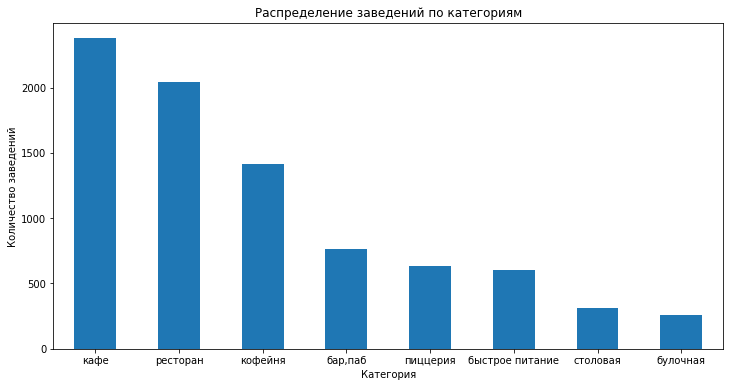

In [33]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 6))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df['category'].value_counts().plot(
               kind='bar',
               rot=0,
               legend=False,
               title=f'Распределение заведений по категориям'
)

# Настраиваем оформление графика
plt.xlabel('Категория')
plt.ylabel('Количество заведений')

# Выводим график
plt.show()


Большинство заведений, представленных в датафрейме, относятся к категориям `кафе`, `ресторан` и `кофейня`. А самыми не популярными категориями являются `столовая` и `булочная`.

---

### Задача 2

Находим все административные районы Москвы, которые присутствуют в данных.

In [34]:
# Выводим названия всех административных районов Москвы, представленных в данных
df['district'].unique()

['Северный административный округ', 'Северо-Восточный административный округ', 'Северо-Западный административный округ', 'Западный административный округ', 'Центральный административный округ', 'Восточный административный округ', 'Юго-Восточный административный округ', 'Южный административный округ', 'Юго-Западный административный округ']
Categories (9, object): ['Северный административный округ', 'Северо-Восточный административный округ', 'Северо-Западный административный округ', 'Западный административный округ', ..., 'Восточный административный округ', 'Юго-Восточный административный округ', 'Южный административный округ', 'Юго-Западный административный округ']

В данных представлены 9 административных районов Москвы: `Северный административный округ`, `Северо-Восточный административный округ`, `Северо-Западный административный округ`, `Западный административный округ`, `Центральный административный округ`, `Восточный административный округ`, `Юго-Восточный административный округ`, `Южный административный округ`, и `Юго-Западный административный округ`.

#### Распределение заведений по административным районам Москвы

Изучаем распределение заведений по административным районам Москвы.

In [35]:
# Посчитаем количество заведений для каждого значения столбца district
print('Распределение заведений по значениям столбца district:')
df['district'].value_counts()

Распределение заведений по значениям столбца district:


Центральный административный округ         2242
Северный административный округ             900
Южный административный округ                892
Северо-Восточный административный округ     891
Западный административный округ             851
Восточный административный округ            798
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Северо-Западный административный округ      409
Name: district, dtype: int64

Визуализируем результат для наглядности.

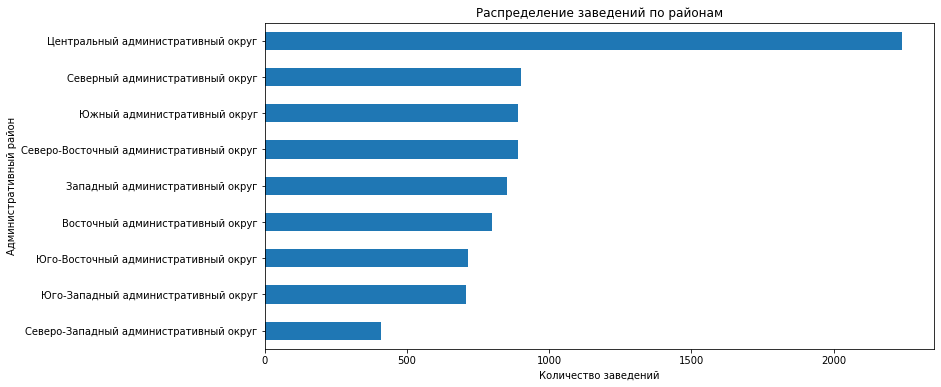

In [36]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 6))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='barh')
df['district'].value_counts().sort_values(ascending=True).plot(
               kind='barh',
               rot=0,
               legend=False,
               title=f'Распределение заведений по районам'
)

# Настраиваем оформление графика
plt.xlabel('Количество заведений')
plt.ylabel('Административный район')

# Выводим график
plt.show()

Большая часть заведений расположена в `Центральном административном округе` Москвы. Их в этом округе 2242. Этот округ на порядок опережает все остальные округа. А в `Северо-Западном административном округе` распложены всего 409 заведений. В остальных округах цифры соизмеримы от 709 до 900 заведений.

#### Распределение заведений в Центральном административном округе Москвы

Изучаем распределение заведений каждой категории в `Центральном административном округе` Москвы.

In [37]:
# Посчитаем количество заведений каждой категории в Центральном административном округе Москвы
print('Распределение заведений по категориям в Центральном административном округе:')
df[df['district'] == 'Центральный административный округ'].groupby('category')['id'].nunique().sort_values(ascending=False)

Распределение заведений по категориям в Центральном административном округе:


category
ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: id, dtype: int64

Визуализируем результат для наглядности.

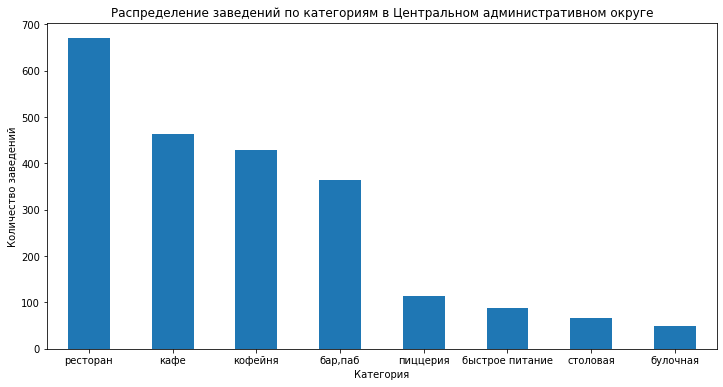

In [38]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 6))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df[df['district'] == 'Центральный административный округ'].groupby('category')['id'].nunique().sort_values(ascending=False).plot(
               kind='bar',
               rot=0,
               legend=False,
               title=f'Распределение заведений по категориям в Центральном административном округе'
)

# Настраиваем оформление графика
plt.xlabel('Категория')
plt.ylabel('Количество заведений')

# Выводим график
plt.show()

В `Центральном административном округе` Москвы представлены все 8 категорий заведений. В отличии от обще Московских показателей, где лидирует категория – `кафе`, в этом районе с отрывом лидирует категория – `ресторан` с 670 заведениями. Возможно, это связано с более платежеспособной аудиторией клиентов, проживающих в Центральном районе. Так как `рестораны` обычно более дорогие заведения, чем `кафе`. На втором и третьем месте категории – `кафе` и `кофейня` с 464 и 428 заведениями соответственно. А аутсайдеры те же – `столовая` и `булочная`.

---

### Задача 3

Изучаем сетевые и несетевые заведения в целом по всем данным. 

In [39]:
# Изучаем соотношение сетевых и несетевых заведений в целом по всем данным
total = df['id'].count()
chained = df['chain'].sum()
unchained = total - chained
print(f"Количество сетевых заведений: {chained} или {round(chained / total * 100, 2)}% от общего числа заведений.")
print(f"Количество несетевых заведений: {unchained} или {round(unchained / total * 100,2)}% от общего числа заведений.")

Количество сетевых заведений: 3205 или 38.13% от общего числа заведений.
Количество несетевых заведений: 5201 или 61.87% от общего числа заведений.


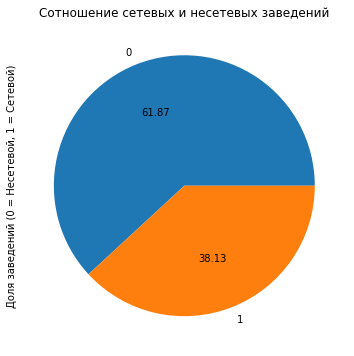

In [40]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 6))

# Строим круговую диаграмму с помощью pandas через plot(kind='pie')
df.groupby('chain')['id'].count().plot(
                kind='pie', 
                rot=0,
                legend=False,
                autopct='%.2f', 
                title='Cотношение сетевых и несетевых заведений'
)

# Настраиваем оформление графика
plt.ylabel('Доля заведений (0 = Несетевой, 1 = Сетевой)')

# Выводим график
plt.show()

В данных несетевых заведений гораздо больше, чем сетевых.

Изучаем сетевые и несетевые заведения в каждой категории.

In [41]:
# Посчитаем общее количество заведений в каждой категории
total_per_category = df.groupby('category')['chain'].count()

# Получим количество несетевых и сетевых заведений в каждой категории
counts = df.groupby(['category', 'chain'])['chain'].count().unstack()

# Рассчитаем доли несетевых и сетевых заведений в каждой категории
shares = counts.div(total_per_category, axis=0).sort_values(by=1, ascending=False)

# Выводим доли сетевых заведений в каждой категории
print('Доля сетевых заведений в каждой категории:')
print(round(shares[1] * 100, 2))

Доля сетевых заведений в каждой категории:
category
булочная           61.33
пиццерия           52.13
кофейня            50.96
быстрое питание    38.47
ресторан           35.73
кафе               32.76
столовая           27.94
бар,паб            22.09
Name: 1, dtype: float64


Визуализируем результат для наглядности.

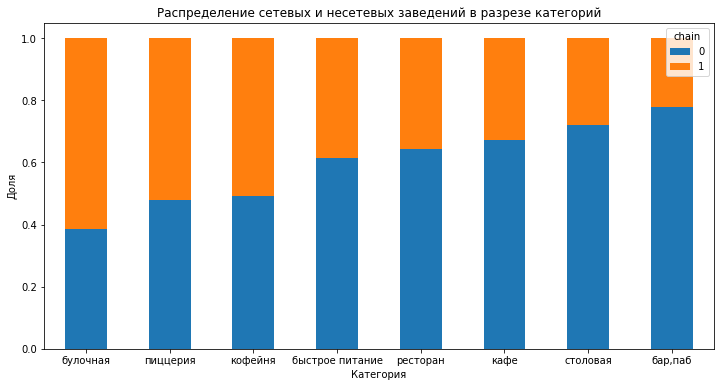

In [42]:
# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
shares.plot(kind='bar', stacked=True, figsize=(12, 6), rot=0)

# Настраиваем оформление графика
plt.title('Распределение сетевых и несетевых заведений в разрезе категорий')
plt.xlabel('Категория')
plt.ylabel('Доля')

# Выводим график
plt.show()

В пяти категориях, а именно в категориях: `кафе`, `ресторан`, `паб,бар`, `быстрое питание` и `столовая`, несетевых заведений больше, чем сетевых. И разница между ними значительная, а в случаях категории: `кафе`, `бар,паб` и `столовая` – она кратная. В трех категориях, а именно в категориях: `кофейня`, `пиццерия` и `булочная`, сетевых заведений больше, чем сетевых. Но разница не столь значительна.

---

### Задача 4

Исследуем посадочные места в заведениях.

In [43]:
# Изучаем статистические показатели столбца seats
print('Статистические показатели столбца seats:')
df['seats'].describe()

Статистические показатели столбца seats:


count    4795.000000
mean      108.421689
std       122.833396
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

Можно предположить, что данные о количестве посадочных мест в заведениях имеют ненормальное (ассиметричное) распределение. Об этом говорит значительный разброс между средним и медианным значением. Возможно, имеет место правосторонняя скошенность учитывая то, что среднее больше медианы. Также разница между минимальным и максимальным значениями огромна, что говорит о наличии выбросов. Кроме этого, сами минимальные и максимальные значения выглядят аномальными. 
- Отсутствие посадочных мест, может говорить о том, что заведение работает на вынос или является «Dark Kitchen» какой ни будь сети.
- Заведения с более 1000 посадочных мест, имеют место быть, например в Южном Казахстане или Средней Азии, где такое количество допустимо во «Дворцах торжеств» («Тойхана»), но в Москве, кажется, маловероятным.


Визуализируем результат для наглядности.

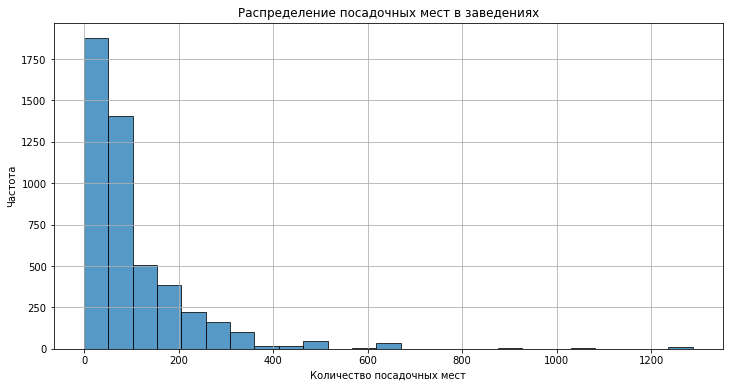

In [44]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 6))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df['seats'].plot(
                kind='hist',
                bins=25,
                alpha=0.75,
                edgecolor='black',
                rot=0,
)

# Настраиваем оформление графика
plt.title('Распределение посадочных мест в заведениях')
plt.xlabel('Количество посадочных мест')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

И в правду, данные о количестве посадочных мест в заведениях имеют правоасимметричные распределения с длинным правым «хвостом».

Вычисляем верхний порог для выбросов.

In [45]:
# Рассчитываем межквартильный размах IQR
iqr = df['seats'].quantile(0.75) - df['seats'].quantile(0.25)
# Вычисляем верхний порог для выбросов
outliers = df['seats'].quantile(0.75) + 1.5 * iqr
# Выводим на экран верхний порог для выбросов
print(f'Верхний пороги для выбросов в распределении посадочных мест равен: {outliers}')

Верхний пороги для выбросов в распределении посадочных мест равен: 290.0


Верхний пороги для выбросов в распределении посадочных мест равен: 290.

Визуализируем выбросы диаграммой размаха («ящиком с усами»).

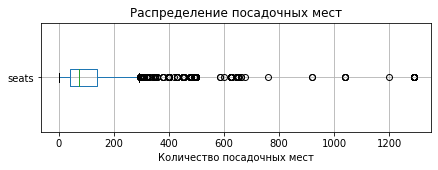

In [46]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце balance
df.boxplot(column='seats', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение посадочных мест')
plt.xlabel('Количество посадочных мест')

# Выводим график
plt.show()

Посчитаем для каждой категории заведений наиболее типичное для него количество посадочных мест. Учитываем только значения меньше найденного порога выбросов.

In [47]:
# Считаем для каждой категории заведений наиболее типичное для него количество посадочных мест
df[df['seats'] < 290].groupby('category')['seats'].agg(['mean', lambda x: x.quantile(0.5)]).rename(columns={'<lambda_0>': 'median'}).sort_values(by='mean', ascending=False)

,mean,median
category,,
ресторан,96.309787,80.0
"бар,паб",88.484634,77.0
кофейня,84.548991,70.0
быстрое питание,81.164634,60.0
столовая,78.554839,70.0
пиццерия,76.837438,50.0
кафе,75.489974,54.0
булочная,75.148936,48.0


Визуализируем результат для наглядности.

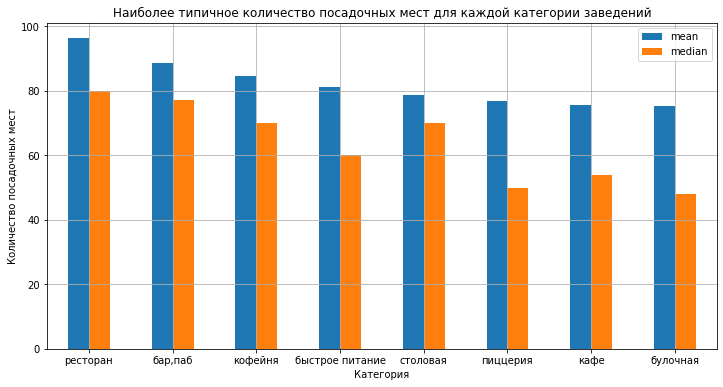

In [48]:
# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df[df['seats'] < 290].groupby('category')['seats'].agg(['mean', lambda x: x.quantile(0.5)]).rename(columns={'<lambda_0>': 'median'}).sort_values(by='mean', ascending=False).plot(
                kind='bar',
                rot=0,
                legend=True,
                figsize=(12, 6),
                title=f'Наиболее типичное количество посадочных мест для каждой категории заведений'
)

# Настраиваем оформление графика
plt.xlabel('Категория')
plt.ylabel('Количество посадочных мест')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Однозначно назвать типичное количество посадочных мест для каждой категории заведений довольно сложно. Судя по статистическим показателям, присутствует правосторонняя (положительная) скошенность во всех категориях. О чем свидетельствует средняя (`mean`), которая больше медианы. Средняя и медиана ближе всего в категории `столовая`, поэтому можно с большей уверенностью говорить, что наиболее типичное количество посадочных мест для этой категории 70+ посадочных мест. Наибольшее количество посадочных мест в категориях – `ресторан`, `бар, паб` и `кофейня`, где средняя ровна – 96, 88 и 85 посадочным местам соответственно.

---

### Задача 5

Исследуем рейтинги заведений.

In [49]:
# Изучаем статистические показатели столбца rating
print('Статистические показатели столбца rating:')
df['rating'].describe()

Статистические показатели столбца rating:


count    8406.000000
mean        4.229895
std         0.470348
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

Можно предположить, что данные о рейтингах заведений имеют распределение, близкое к нормальному. Об этом говорит близость среднего и медианного значений. Однако распределение может иметь длинный хвост с слева. Разница между минимальным и максимальным значениями это подтверждает.

Визуализируем результат для наглядности.

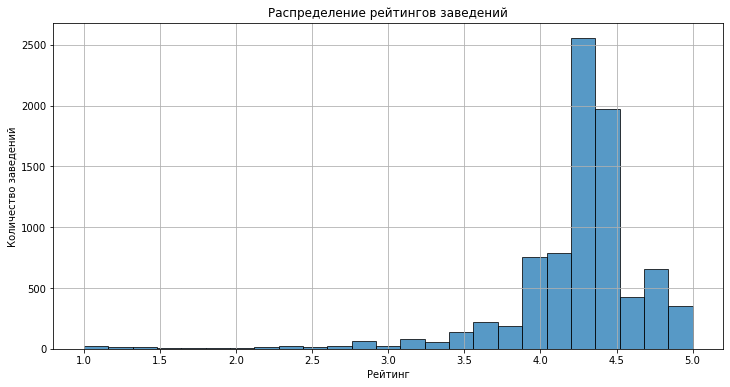

In [50]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 6))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df['rating'].plot(
                kind='hist',
                bins=25,
                alpha=0.75,
                edgecolor='black',
                rot=0,
)

# Настраиваем оформление графика
plt.title('Распределение рейтингов заведений')
plt.xlabel('Рейтинг')
plt.ylabel('Количество заведений')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Данные о рейтингах заведений имеет нормальное распределение с длинным левым «хвостом».

Изучаем средний рейтинг по категориям заведений.

In [51]:
# Выводим средний рейтинг по категориям заведений
df.groupby('category')['rating'].mean()

category
бар,паб            4.387712
булочная           4.268359
быстрое питание    4.050249
кафе               4.123886
кофейня            4.277282
пиццерия           4.301264
ресторан           4.290357
столовая           4.211429
Name: rating, dtype: float32

Средний рейтинг по категориям заведений не сильно различается, он колеблется между 4.0 и 4.4, что соответствует среднему рейтингу по всем категориям (4.2). Самый низкий средний рейтинг у категории `быстрое питание`, а самый высокий средний рейтинг у категории `бар, паб`.

Визуализируем распределение рейтингов по категориям заведений.

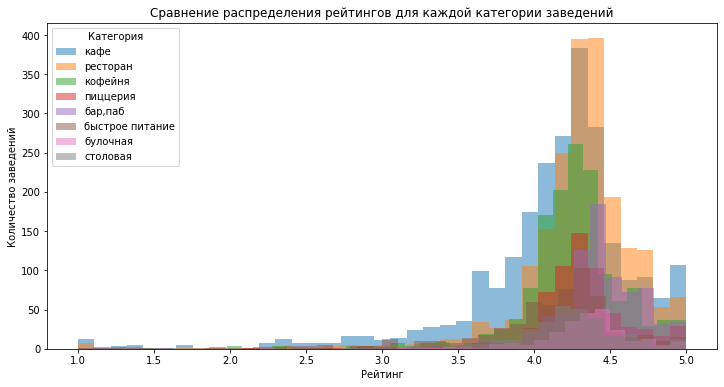

In [52]:
# Строим гистограмму распределения рейтингов заведений
# Создаём фигуру графика
plt.figure(figsize=(12, 6))

# Строим гистограммы для каждой категории
for i in df['category'].unique():
    # Фильтруем данные по категории
    df.loc[df['category'] == i, 'rating'].plot(
        kind='hist',
        bins=37,
        alpha=0.5,
        label=f'{i}',
        legend=True
    )

# Настраиваем внешний вид графика и выводим его на экран
plt.title(f'Сравнение распределения рейтингов для каждой категории заведений')
plt.xlabel('Рейтинг')
plt.ylabel('Количество заведений')
plt.legend(title='Категория')
plt.show()

Усреднённые рейтинги для разных типов общепита не сильно различаются. Большинство заведений получают рейтинг от 4.0 до 4.5. Незначительное количество заведений получают от 3.0 до 3.5. Считанное количество заведений получают низкий рейтинг. Существенное количество заведений получают наивысший рейтинг. Почти во всех категориях заметен всплеск в правом «хвосте» распределения.

---

### Задача 6

Изучаем корреляцию рейтинга с другими данными заведений.

In [53]:
# Вычисляем корреляционную матрицу с использованием phi_k
correlation_matrix = df[['category', 'district', 'chain', 'seats', 'price', 'is_24_7', 'rating']].phik_matrix()

# Выводим результат
print('Корреляционная матрица с коэффициентом phi_k для переменной rating')
correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

interval columns not set, guessing: ['chain', 'seats', 'rating']
Корреляционная матрица с коэффициентом phi_k для переменной rating


,rating
price,0.262056
category,0.198949
district,0.189389
is_24_7,0.185718
chain,0.119071
seats,0.000000


Визуализируем результат для наглядности.

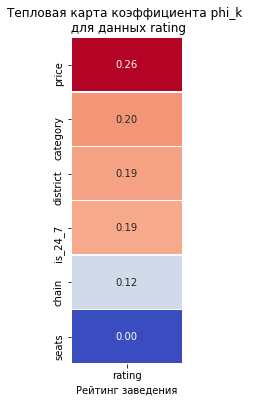

In [54]:
# Строим тепловую карту
plt.figure(figsize=(2, 6))

# Сохраняем матрицу корреляции признака rating с другими данными заведения общественного питания
data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)
sns.heatmap(data_heatmap,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5,
            cbar=False
           )

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k \n для данных rating')
plt.xlabel('Рейтинг заведения')

# Выводим график
plt.show()

Почти все данные, кроме столбца `seats` (количество посадочных мест), показывают слабую положительную корреляцию (0<r≤0.3). Другими словами, присутствует небольшая положительная связь, но влияние одной переменной на другую минимально. Между столбцами `rating` и `seats` нет связи. Самая большая связь у столбца `rating` со столбцом `price`.

Проверяем связь между столбцами `rating` и `price`.

In [55]:
# Рассчитываем медианное значение каждой ценовой категории
df.groupby('price')['middle_avg_bill'].agg(lambda x: x.quantile(0.5))

price
высокие          2000.0
выше среднего    1250.0
низкие            180.0
средние           500.0
Name: middle_avg_bill, dtype: float64

In [56]:
# Создаем словарь, который содержит медианное значение ценовой категории
category_mapping = df.groupby('price')['middle_avg_bill'].agg(lambda x: x.quantile(0.5))

# Создаем столбец в датафрейме, который содержит медианное значение ценовой категории
df['price_numeric'] = df['price'].map(category_mapping)

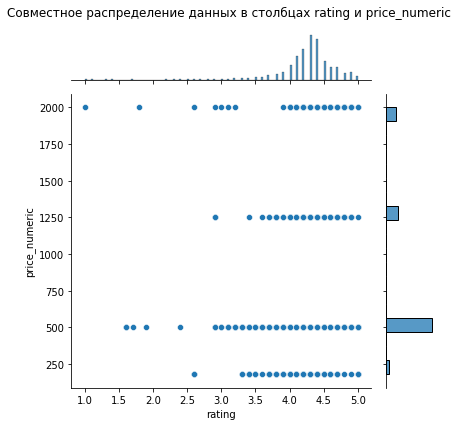

In [57]:
# Построим график совместного распределения для столбцов `score` и `price_numeric`
sns.jointplot(data=df, x='rating', y='price_numeric')

# Подписываем и отображаем график
plt.suptitle('Совместное распределение данных в столбцах rating и price_numeric')
plt.tight_layout()
plt.show()

Между столбцами `rating` и `price` имеется слабая положительную корреляцию (0<r≤0.3). Однако, сложно сказать, что c повышением ценовой категории повышается и рейтинг заведения общественного питания. Хорошие рейтинги получают, как заведения с `низкой`, так и `высокой` ценовой категорией. Большая часть заведений в данных представлены в `средней` ценовой категории.

---

### Задача 7

Сгруппируйте данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитайте значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводите подходящими визуализациями.

Изучаем самые популярные сети заведений общественного питания в Москве.

In [58]:
# Создаем датафрейм с нужными сгруппированными данными
top_15_chains = df[df['chain'] == 1].groupby(['name']).agg({'id': 'count', 'rating': 'mean', 'category': 'first'}).sort_values(by='id', ascending=False).head(15)

In [59]:
# Выводим топ-15 популярных сетей в Москве
top_15_chains[['id', 'category']]

,id,category
name,,
шоколадница,120,кофейня
домино'с пицца,76,пиццерия
додо пицца,74,пиццерия
one price coffee,71,кофейня
яндекс лавка,69,ресторан
cofix,65,кофейня
prime,50,ресторан
хинкальная,44,быстрое питание
кофепорт,42,кофейня


Визуализируем результат.

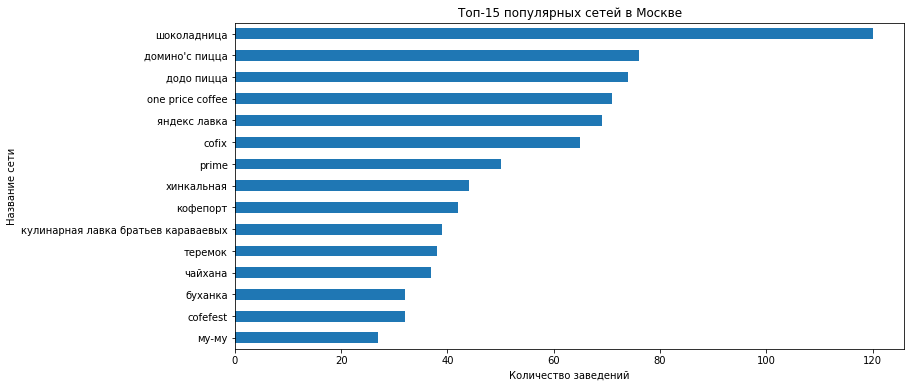

In [60]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 6))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
top_15_chains['id'].sort_values(ascending=True).plot(
               kind='barh',
               rot=0,
               legend=False,
               title=f'Топ-15 популярных сетей в Москве'
)

# Настраиваем оформление графика
plt.xlabel('Количество заведений')
plt.ylabel('Название сети')

# Выводим график
plt.show()

Самой популярной сетью в Москве является кофейня `шоколадница`. У нее 120 точек в городе, и она с отрывом опережает ближайших конкурентов. За ней следом идут две пиццерии `домино'с пицца` и `додо пицца` с 76 и 74 точками соответственно.

In [61]:
# Выводим рейтинги самых популярных сетей и сортируем их по рейтингу
top_15_chains[['rating', 'category']].sort_values(by='rating', ascending=False)

,rating,category
name,,
буханка,4.396875,булочная
кулинарная лавка братьев караваевых,4.394872,кафе
хинкальная,4.322727,быстрое питание
додо пицца,4.286487,пиццерия
му-му,4.229630,кафе
шоколадница,4.177500,кофейня
домино'с пицца,4.169737,пиццерия
кофепорт,4.147619,кофейня
теремок,4.123684,ресторан


Визуализируем результат.

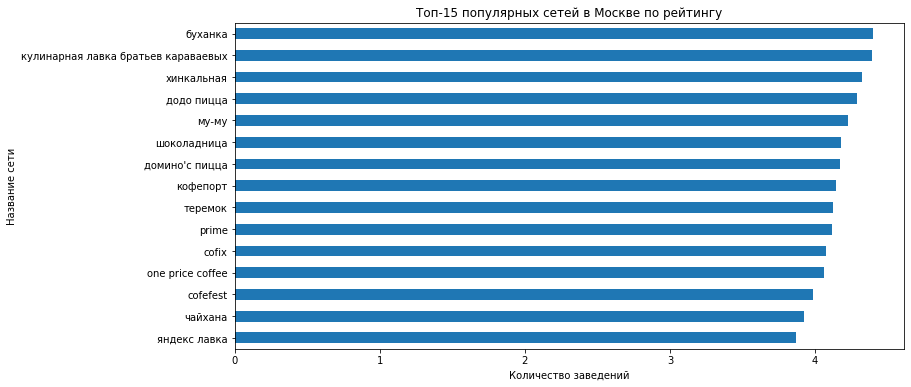

In [62]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 6))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
top_15_chains['rating'].sort_values(ascending=True).plot(
               kind='barh',
               rot=0,
               legend=False,
               title=f'Топ-15 популярных сетей в Москве по рейтингу'
)

# Настраиваем оформление графика
plt.xlabel('Количество заведений')
plt.ylabel('Название сети')

# Выводим график
plt.show()

Рейтинги топ-15 самых популярных заведений в Москве соизмеримы и варьируются между 3.9 и 4.4. Самые высокие рейтинги у `булочной` `буханка` и `кафе` `кулинарная лавка братьев караваевых`, разница у их рейтингов незначительна.

In [63]:
# Считаем количество сетей и заведений представленных в топ-15 самых популярных заведений в Москве по категориям
top_15_chains.groupby('category')['id'].agg(['count', 'sum']).sort_values(by='sum', ascending=False)

,count,sum
category,,
кофейня,5,330
ресторан,3,157
пиццерия,2,150
кафе,3,103
быстрое питание,1,44
булочная,1,32


В топ-15 самых популярных сетей общественного питания входят: 5 `кофейни`, по 3 `ресторана` и `кафе`, 2 `пиццерии` и по одной `булочной` и сети `быстрого питания`. По количеству заведений в выборке также лидируют `кофейни` с большим отрывом – 330 заведений. Хотя в выборке представлены только две `пиццерии`, количество заведений входящих в них значительно – 150, что говорит о большой консолидации на рынке категории.

---

### Задача 8

Изучаем вариацию среднего чека заведения в зависимости от района Москвы.

In [64]:
# Изучаем статистические показатели среднего чека заведения в зависимости от района Москвы
df[df['middle_avg_bill'] != 0].groupby('district')['middle_avg_bill'].agg(['count', 'min', 'max', 'mean', pd.Series.mode, lambda x: x.quantile(0.5)]).rename(columns={'<lambda_0>': 'median'}).sort_values(by='mean', ascending=False)

,count,min,max,mean,mode,median
district,,,,,,
Центральный административный округ,1059,67.0,7250.0,1192.182247,1250.0,1000.0
Западный административный округ,306,50.0,5250.0,1053.225490,1250.0,1000.0
Северный административный округ,322,130.0,11000.0,927.959627,500.0,650.0
Южный административный округ,314,100.0,35000.0,834.398089,1250.0,500.0
Северо-Западный административный округ,157,120.0,2900.0,822.222930,1250.0,700.0
Восточный административный округ,260,50.0,10000.0,820.626923,1250.0,575.0
Юго-Западный административный округ,235,100.0,2750.0,792.561702,1250.0,600.0
Северо-Восточный административный округ,301,50.0,4500.0,716.611296,300.0,500.0
Юго-Восточный административный округ,194,30.0,3750.0,654.097938,300.0,450.0


Статистические показатели среднего чека заведения в зависимости от района Москвы, дают много пищи для размышления. `Центральный административный округ` лидирует по среднему показателю среднего чека заведения, где он равен 1192 рублю. Также учитывая относительную близость среднего и медианного значений, можно предположить, что данные имеют распределение, близкое к нормальному с правым «хвостом». Похожие показатели и у `Западного административного округа`. В других административных округах распределение среднего чека заведения скорее всего имеют ненормальное (ассиметричное) распределение. Самые дорогие заведения находятся в `Северном административном округе` и `Восточном административном округе`, где встречаются заведения со средним чеком 35.000 и 11.000 рублей соответственно. Самый распространённый типичный чек в Москве 1250 рублей, он является таковым в 6 шести округах из 9. В трех оставшихся округах этот показатель значительно ниже. Самые низкие показатели среднего чека заведения зафиксированы в `Юго-Восточном административном округе`, где средний показатель среднего чека равен 654 рублям, а самый распространённый средний чек – 300 рублей.

Визуализируем средние показатели среднего чека заведения в зависимости от района Москвы.

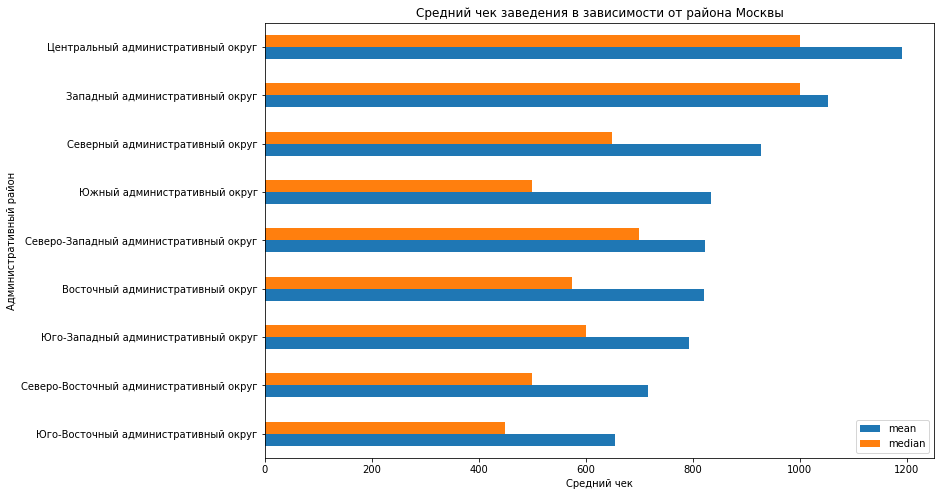

In [65]:
# Строим столбчатую диаграмму с помощью pandas через plot(kind='barh')
df[df['middle_avg_bill'] != 0].groupby('district')['middle_avg_bill'].agg(['mean', lambda x: x.quantile(0.5)]).rename(columns={'<lambda_0>': 'median'}).sort_values(by='mean', ascending=True).plot(
                kind='barh',
                rot=0,
                legend=True,
                figsize=(12, 8),
                title=f'Cредний чек заведения в зависимости от района Москвы'
)

# Настраиваем оформление графика
plt.xlabel('Cредний чек')
plt.ylabel('Административный район')

# Выводим график
plt.show()

Самые большие средние чеки в `Центральном административном округе`, а самые низкие – в `Юго-Восточном административном округе`. Административные округа Москвы равноудалены от `Центрального административного округа`, поэтому сложно судить о влиянии удалённости от центра на цены в заведениях. Скорее можно говорить о престижности одних районов от других. Так, например, цены в `Западном административном округе` не сильно отличаются от `Центрального`, а в `Юго-Восточном` – почти в два раза ниже. Также стоит упомянуть о наличии аномальных заведений, где средние чеки порой могут в десятки раз могут превышать средние по району. Однако, можно однозначно говорить, что средние цены в «периферийных» округах ниже, чем в `Центральном`.

---

### Промежуточный вывод

В результате исследовательского анализа данных были сделаны следующие выводы:
- Большинство заведений, представленных в данных, относятся к категориям `кафе` и `ресторан`. 
- Самыми «непопулярными» категориями являются `столовая` и `булочная`.
- Большая часть заведений расположена в `Центральном административном округе` Москвы.
- В трех категориях, а именно в категориях: `кофейня`, `пиццерия` и `булочная`, сетевых заведений больше, чем сетевых.
- Для `ресторана` наиболее типичное количество посадочных мест около 100, а для категории `бар, паб` и `кофейня` – чуть меньше 90. В `столовых` обычно чуть больше 70 посадочных мест. В остальных категориях замечен очень большой разброс между среднем и медианным значением.
- Большинство заведений получают рейтинг от 4.0 до 4.5.
- Рейтинг заведения имеет слабую положительную корреляцию (0<r≤0.3) с ценовой категорией. Другими словами, присутствует небольшая положительная связь, но влияние одной переменной на другую минимально.
- Самой популярной сетью в Москве является кофейня `шоколадница`. За ней следом идут две пиццерии `домино'с пицца` и `додо пицца` с 76 и 74 точками соответственно.
- В топ-15 самых популярных сетей общественного питания входят: 5 `кофейни`, по 3 `ресторана` и `кафе`, 2 `пиццерии` и по одной `булочной` и сети `быстрого питания`.
- Самые большие средние чеки в `Центральном административном округе`, а самые низкие – в `Юго-Восточном административном округе`.


<a id='chapter_four'></a>
## 4. Итоговый вывод и рекомендации

В ходе исследования проанализировали данные на лето 2022 года о 8406 заведений общественного питания из 9 районов Москвы. Данные включали справочную информацию, рейтинг, сетевую принадлежность, количество посадочных мест, а также информацию о ценовой политике заведений. Акцент исследования был на общем анализе рынка общественного питания. Особое внимание исследования было уделено категориям, сетевой принадлежности, и району расположения заведений общественного питания. При рассмотрении популярности заведения были учтены рейтинги, количество посадочных мест и количество заведений.

### Общий обзор проделанной работы

Во время исследования были проделаны следующие работв:
- Проведена загрузка и знакомство с данными двух датасетов датасетов `/datasets/rest_info.csv` и `/datasets/rest_price.csv`.
- Подготовлен единый датафрейм, проведена предобработка дынных с оптимизацией данных, а также создан дополнительный столбец с обозначением того, что заведение работает ежедневно и круглосуточно.
- Проведен исследовательский анализ с решением 8 задач.


### Ответы на исследовательские вопросы

1. В данных представлены 8 категорий. Большинство заведений, представленных в датафрейме, относятся к категориям `кафе` и `ресторан`. На третьем месте категория `кофейни`. Самыми «непопулярными» категориями являются `булочная` и `столовая`.
2. В данных представлены 9 административных районов Москвы. Большая часть заведений расположена в Центральном административном округе Москвы.
3. В данных несетевых заведений почти в два раза больше, чем сетевых. Однако, в трех категориях, а именно в категориях: `кофейня`, `пиццерия` и `булочная`, сетевых заведений больше, чем сетевых.
4. Для `ресторана` наиболее типичное количество посадочных мест около 100, а для категории `бар, паб` и `кофейня` – чуть меньше 90. В `столовых` обычно чуть больше 70 посадочных мест. В остальных категориях замечен очень большой разброс между среднем и медианным значением.
5. Усреднённые рейтинги для разных типов общепита не сильно различаются. Большинство заведений получают рейтинг от 4.0 до 4.5.
6. Рейтинги заведений показывают самую сильную связь с ценовой категорией. Однако, эта связь представляет собой – слабую положительную корреляцию (0<r≤0.3). Другими словами, присутствует небольшая положительная связь, но влияние одной переменной на другую минимально.
7. Самой популярной сетью в Москве является кофейня `шоколадница`. За ней следом идут две пиццерии `домино'с пицца` и `додо пицца`. В топ-15 самых популярных сетей общественного питания входят: 5 `кофейни`, по 3 `ресторана` и `кафе`, 2 `пиццерии` и по одной `булочной` и сети `быстрого питания`. По количеству заведений в выборке также лидируют `кофейни` с большим отрывом – 330 заведений.
8. Самые большие средние чеки в `Центральном административном округе`, а самые низкие – в `Юго-Восточном административном округе`. Административные округа Москвы равноудалены от `Центрального административного округа`, поэтому сложно судить о влиянии удалённости от центра на цены в заведениях. Скорее можно говорить о престижности одних районов от других. Однако, можно однозначно говорить, что средние цены в «периферийных» округах ниже, чем в `Центральном`.


### Рекомендации

Инвестору в первую очередь стоит задуматься о масштабе проекта – будет ли заведение одним в своем роде или частью сети. Если инвестор хочет открыть одно заведение, то лучше присмотреться к категориям кафе, ресторан и паб, бар, где большая часть заведений – уникальные. В таких категориях, как кофейня, пиццерия и булочная преобладают сети. И если цель инвестора создать сеть или купить франшизу, то лучше присмотреться к этим категориям.

Самая большая конкуренция зафиксирована в Центральном административном округе, в этом же районе самые большие средние чеки. Но для открытия первого заведения следует присмотреться к Западному административному округу. Там конкуренция выглядит ниже, а средние чеки соизмеримы с центральным районом. Тем не менее для более точной оценки перспективности района лучше дополнительно проанализировать плотность населения в районе и род деятельности домохозяйств.

Самый распространённый типичный чек в Москве 1250 рублей, он является таковым в 6 шести округах из 9. При ценообразовании следует отталкиваться от этой цифры.

Кроме этого, следует учитывать, что большинство заведений получают рейтинг от 4.0 до 4.5. При поиске франшизы или покупке готового заведения следует учитывать этот показатель. Если рейтинг заведения существенно ниже этого показателя лучше воздержаться от инвестиции в заведение.

Корреляция между рейтингом и ценой незначительна. Высокий средний чек не значит высокие рейтинги, и соответственно низкие цены не всегда ведут к низким или высоким рейтингам. Хорошие рейтинги можно получить во всех категориях, как ценовых, так и концептуальных.